A notebook comparing how llama did vs. using rule-based/regex matching to classify contract types.

In [1]:
import pandas as pd

In [2]:
labelled_data = pd.read_csv('contract_evaluation - contract_type_llama_labelled_for_eval.csv')

In [3]:
# Normalize text labels by converting them to lowercase
labelled_data['human_label'] = labelled_data['human_label'].str.lower()
labelled_data['classified_contract_type'] = labelled_data['classified_contract_type'].str.lower()
labelled_data['contract_type_llama'] = labelled_data['contract_type_llama'].str.lower()

# Remove any NaN values before evaluation
labelled_data_cleaned = labelled_data.dropna(subset=['human_label', 'classified_contract_type', 'contract_type_llama'])

In [4]:
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

metrics = {}
for col in ['classified_contract_type', 'contract_type_llama']:
    accuracy = accuracy_score(labelled_data_cleaned['human_label'], labelled_data_cleaned[col])
    precision, recall, f1, _ = precision_recall_fscore_support(labelled_data_cleaned['human_label'], labelled_data_cleaned[col], average='weighted')
    
    metrics[col] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Classification Report': classification_report(labelled_data_cleaned['human_label'], labelled_data_cleaned[col])
    }

# Display the results
metrics

/Users/rosie.oxbury/miniconda3/envs/dap_job_quality/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/rosie.oxbury/miniconda3/envs/dap_job_quality/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/rosie.oxbury/miniconda3/envs/dap_job_quality/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _w

{'classified_contract_type': {'Accuracy': 0.8036529680365296,
  'Precision': 0.820261975956999,
  'Recall': 0.8036529680365296,
  'F1 Score': 0.8019711643085132,
  'Classification Report': '              precision    recall  f1-score   support\n\n   permanent       0.61      0.95      0.74        87\n   temporary       0.92      0.72      0.81       256\n     unknown       0.82      0.86      0.84       304\n  zero hours       0.00      0.00      0.00         0\n  zero_hours       0.00      0.00      0.00        10\n\n    accuracy                           0.80       657\n   macro avg       0.47      0.51      0.48       657\nweighted avg       0.82      0.80      0.80       657\n'},
 'contract_type_llama': {'Accuracy': 0.8264840182648402,
  'Precision': 0.8372719930285979,
  'Recall': 0.8264840182648402,
  'F1 Score': 0.8255432068122716,
  'Classification Report': '              precision    recall  f1-score   support\n\n   permanent       0.72      0.91      0.80        87\n   tempor

In [5]:
# Generate classification reports as dictionaries
report_classified = classification_report(labelled_data_cleaned['human_label'], labelled_data_cleaned['classified_contract_type'], output_dict=True)
report_llama = classification_report(labelled_data_cleaned['human_label'], labelled_data_cleaned['contract_type_llama'], output_dict=True)

# Convert to DataFrames
df_classified = pd.DataFrame(report_classified).T
df_llama = pd.DataFrame(report_llama).T



/Users/rosie.oxbury/miniconda3/envs/dap_job_quality/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/rosie.oxbury/miniconda3/envs/dap_job_quality/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/rosie.oxbury/miniconda3/envs/dap_job_quality/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _w

In [6]:
df_classified

,precision,recall,f1-score,support
permanent,0.610294,0.954023,0.744395,87.000000
temporary,0.920000,0.718750,0.807018,256.000000
unknown,0.823344,0.858553,0.840580,304.000000
zero hours,0.000000,0.000000,0.000000,0.000000
zero_hours,0.000000,0.000000,0.000000,10.000000
accuracy,0.803653,0.803653,0.803653,0.803653
macro avg,0.470728,0.506265,0.478398,657.000000
weighted avg,0.820262,0.803653,0.801971,657.000000


In [7]:
df_llama

,precision,recall,f1-score,support
permanent,0.718182,0.908046,0.802030,87.000000
temporary,0.825784,0.925781,0.872928,256.000000
unknown,0.899598,0.736842,0.810127,304.000000
zero_hours,0.272727,0.300000,0.285714,10.000000
accuracy,0.826484,0.826484,0.826484,0.826484
macro avg,0.679073,0.717667,0.692700,657.000000
weighted avg,0.837272,0.826484,0.825543,657.000000


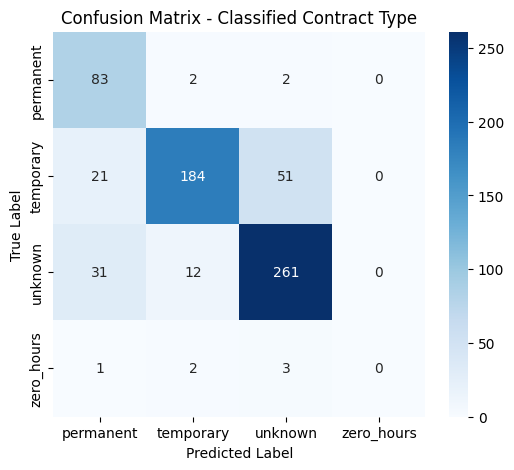

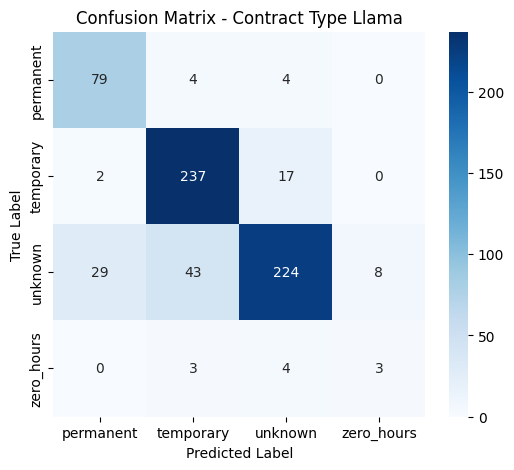

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Define function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=labelled_data_cleaned['human_label'].unique())
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labelled_data_cleaned['human_label'].unique(),
                yticklabels=labelled_data_cleaned['human_label'].unique())
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()
    
plot_confusion_matrix(labelled_data_cleaned['human_label'], labelled_data_cleaned['classified_contract_type'], "Confusion Matrix - Classified Contract Type")
plot_confusion_matrix(labelled_data_cleaned['human_label'], labelled_data_cleaned['contract_type_llama'], "Confusion Matrix - Contract Type Llama")

In [21]:
labelled_data_cleaned[(labelled_data_cleaned['human_label'] != labelled_data_cleaned['classified_contract_type']) & (labelled_data_cleaned['classified_contract_type']=='unknown')][['sentences_split', 'ngrams']].to_csv('unknowns.csv')

# Check which contract phrases are most common

In [9]:
all_jq_data = pd.read_parquet('s3://open-jobs-lake/job_quality/health_social_care/health_jobs_jq_dimensions.parquet')

In [10]:
all_contract_data = all_jq_data[all_jq_data['subcategory']=='CONTRACT']
len(all_contract_data)

60523

In [16]:
len(all_contract_data['ngrams'].unique())

19558

In [24]:
all_contract_data['ngrams'].value_counts()

ngrams
month with our free           344
on a permanent basis          331
ongoing contract Pay Rate     263
bringing your own position    243
a full time permanent         233
                             ... 
standing manager in place       1
in place but generally          1
overview of the position.       1
for Immediate and January       1
contract with X -               1
Name: count, Length: 19558, dtype: int64

In [11]:
all_contract_data['target_phrase'].value_counts()

target_phrase
month contract         13148
permanent contract     10690
Permanent position      8636
long term               5666
contract choice         5604
temporary contract      5185
fixed term              3531
fixed term contract     2579
Temporary position      2218
maternity cover         2120
zero hour               1146
Name: count, dtype: int64